# Step 1. Import Libraries and Load the Data

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [4]:
# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target

# Map diagnosis: 0 = malignant, 1 = benign
df['diagnosis'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


# Step 2. Basic Exploration

In [5]:
# Basic info
print("=== DATASET OVERVIEW ===")
print(f"Total samples: {len(df)}")
print(f"Malignant cases: {(df['diagnosis'] == 'Malignant').sum()} ({(df['diagnosis'] == 'Malignant').mean()*100:.1f}%)")
print(f"Benign cases: {(df['diagnosis'] == 'Benign').sum()} ({(df['diagnosis'] == 'Benign').mean()*100:.1f}%)")
print(f"Number of features: {len(data.feature_names)}")

# Check for missing values
print("\n=== DATA QUALITY ===")
print("Missing values:", df.isnull().sum().sum())


=== DATASET OVERVIEW ===
Total samples: 569
Malignant cases: 212 (37.3%)
Benign cases: 357 (62.7%)
Number of features: 30

=== DATA QUALITY ===
Missing values: 0


# Step 3. Define The Problem Statement

#Comprehensive Analysis of Breast Cancer Diagnostic Factors: Identifying Key Biomarkers for Early Detection and Developing Predictive Models to Assist Clinical Decision-Making

Key Research Questions:

Which cellular characteristics are most strongly associated with malignant tumors?

Can we build a reliable model to classify tumors as benign or malignant?

What are the most important risk factors that clinicians should prioritize?

How do different measurement types (mean, standard error, worst) contribute to diagnosis?

# Step 4. Initial Analysis

In [8]:
# Statistical summary by diagnosis
print("=== FEATURE SUMMARY BY DIAGNOSIS ===")
diagnosis_summary = df.groupby('diagnosis').mean()
print(diagnosis_summary.T.head(10))

# Correlation with diagnosis (convert to numeric for correlation)
df_numeric = df.copy()
df_numeric['diagnosis_num'] = df_numeric['diagnosis'].map({'Malignant': 1, 'Benign': 0})

# Calculate correlations - exclude the original 'diagnosis' column but include 'diagnosis_num'
correlations = df_numeric.drop('diagnosis', axis=1).corr()['diagnosis_num'].sort_values(ascending=False)

print("\n=== TOP FEATURES CORRELATED WITH DIAGNOSIS ===")
print(correlations.head(10))

=== FEATURE SUMMARY BY DIAGNOSIS ===
diagnosis                   Benign   Malignant
mean radius              12.146524   17.462830
mean texture             17.914762   21.604906
mean perimeter           78.075406  115.365377
mean area               462.790196  978.376415
mean smoothness           0.092478    0.102898
mean compactness          0.080085    0.145188
mean concavity            0.046058    0.160775
mean concave points       0.025717    0.087990
mean symmetry             0.174186    0.192909
mean fractal dimension    0.062867    0.062680

=== TOP FEATURES CORRELATED WITH DIAGNOSIS ===
diagnosis_num           1.000000
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
Name: diagnosis_num, dtype: float64


In [10]:
# Get top 5 positive and negative correlations
top_positive = correlations.head(6)[1:]  # Skip diagnosis_num itself
top_negative = correlations.tail(5)

print("\n" + "="*60)
print("KEY INSIGHTS: MOST PREDICTIVE FEATURES")
print("="*60)

print("\n🔴 Features MOST associated with MALIGNANT tumors:")
for feature, corr in top_positive.items():
    print(f"   • {feature:25} (correlation: {corr:+.3f})")

print("\n🟢 Features MOST associated with BENIGN tumors:")
for feature, corr in top_negative.items():
    print(f"   • {feature:25} (correlation: {corr:+.3f})")

# Clinical interpretation
print("\n💡 CLINICAL INTERPRETATION:")
print("Malignant tumors tend to have larger sizes (radius, perimeter, area)")
print("and more irregular shapes (concavity, concave points)")


KEY INSIGHTS: MOST PREDICTIVE FEATURES

🔴 Features MOST associated with MALIGNANT tumors:
   • worst concave points      (correlation: +0.794)
   • worst perimeter           (correlation: +0.783)
   • mean concave points       (correlation: +0.777)
   • worst radius              (correlation: +0.776)
   • mean perimeter            (correlation: +0.743)

🟢 Features MOST associated with BENIGN tumors:
   • fractal dimension error   (correlation: +0.078)
   • symmetry error            (correlation: -0.007)
   • texture error             (correlation: -0.008)
   • mean fractal dimension    (correlation: -0.013)
   • smoothness error          (correlation: -0.067)

💡 CLINICAL INTERPRETATION:
Malignant tumors tend to have larger sizes (radius, perimeter, area)
and more irregular shapes (concavity, concave points)


# Step 5. Visualizations

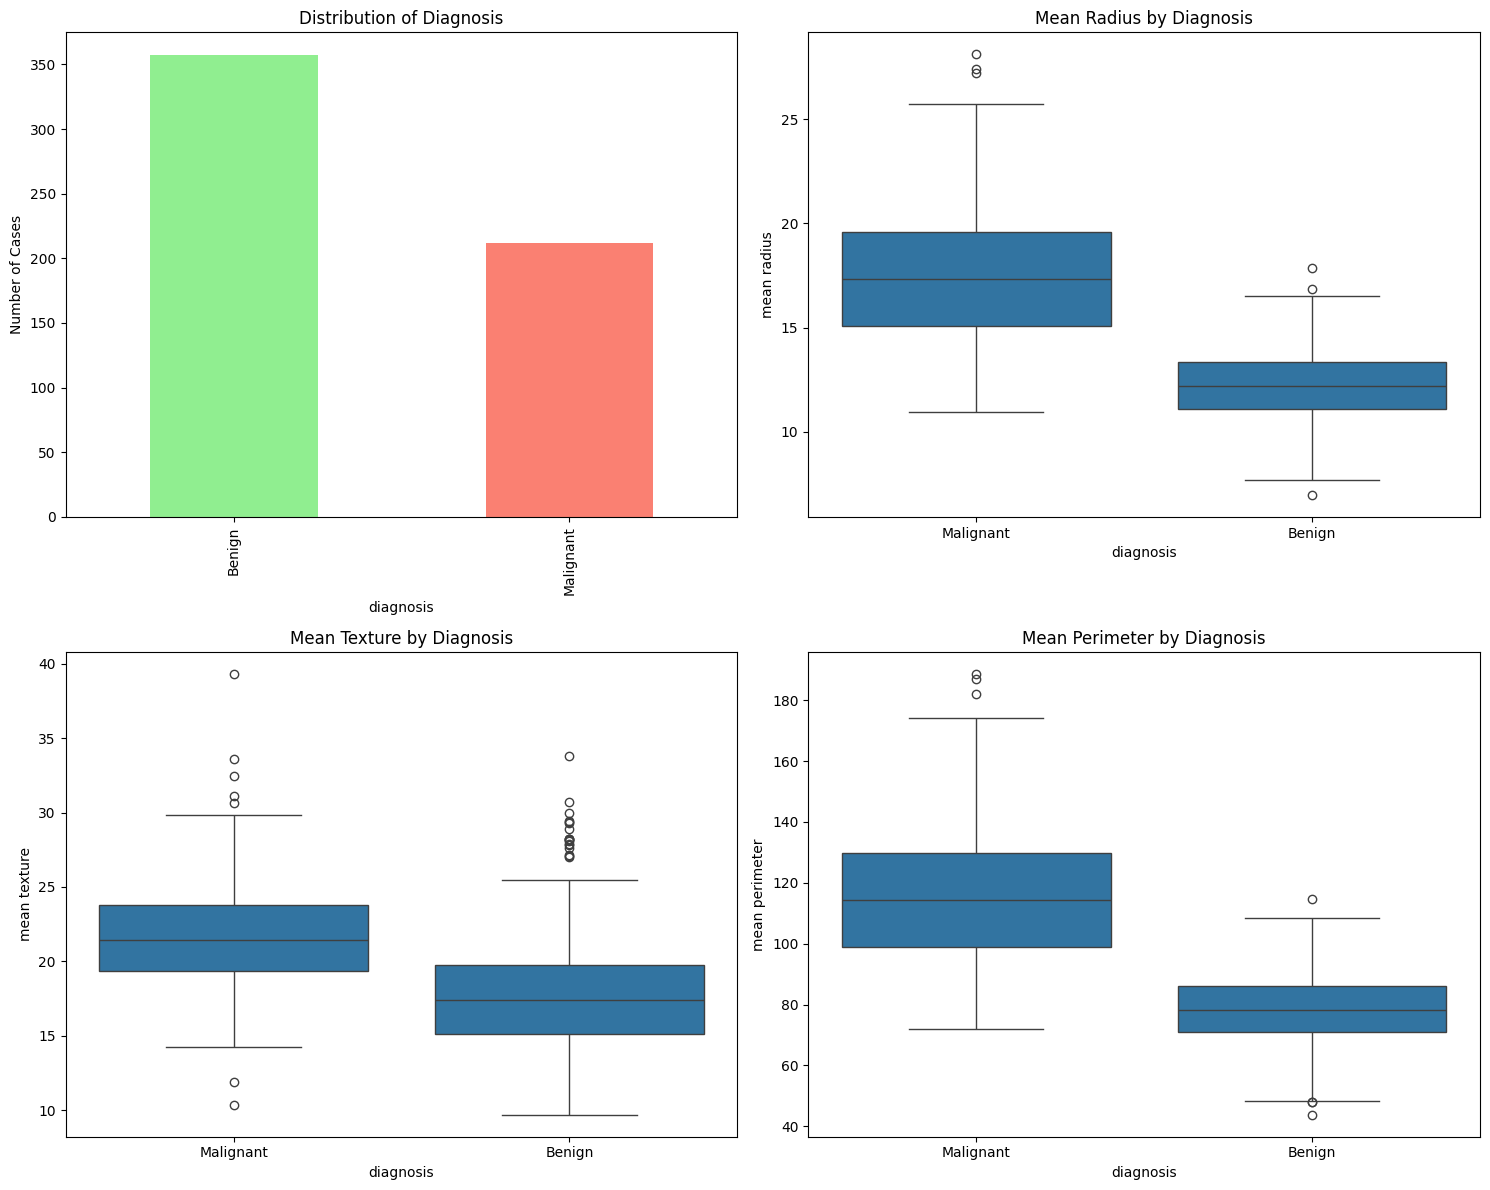

In [12]:
# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Diagnosis distribution
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0,0], color=['lightgreen', 'salmon'])
axes[0,0].set_title('Distribution of Diagnosis')
axes[0,0].set_ylabel('Number of Cases')

# 2. Top correlated features - mean radius
sns.boxplot(data=df, x='diagnosis', y='mean radius', ax=axes[0,1])
axes[0,1].set_title('Mean Radius by Diagnosis')

# 3. Top correlated features - mean texture  
sns.boxplot(data=df, x='diagnosis', y='mean texture', ax=axes[1,0])
axes[1,0].set_title('Mean Texture by Diagnosis')

# 4. Top correlated features - mean perimeter
sns.boxplot(data=df, x='diagnosis', y='mean perimeter', ax=axes[1,1])
axes[1,1].set_title('Mean Perimeter by Diagnosis')

plt.tight_layout()
plt.show()

# Step 6. Advanced Analysis Setup

In [13]:
# Feature categories exploration
print("=== ANALYZING DIFFERENT MEASUREMENT TYPES ===")

# Group features by type
mean_features = [col for col in df.columns if 'mean' in col]
se_features = [col for col in df.columns if 'error' in col]
worst_features = [col for col in df.columns if 'worst' in col]

print(f"Mean features: {len(mean_features)}")
print(f"Standard error features: {len(se_features)}") 
print(f"Worst features: {len(worst_features)}")

=== ANALYZING DIFFERENT MEASUREMENT TYPES ===
Mean features: 10
Standard error features: 10
Worst features: 10


# STEP 7. Feature Importance Analysis

=== FEATURE IMPORTANCE ANALYSIS ===

Top 10 Most Discriminative Features (by mean difference):
 1. worst area                | Mean Difference: 863.39
 2. mean area                 | Mean Difference: 515.59
 3. worst perimeter           | Mean Difference: 54.36
 4. area error                | Mean Difference: 51.54
 5. mean perimeter            | Mean Difference: 37.29
 6. worst radius              | Mean Difference: 7.76
 7. worst texture             | Mean Difference: 5.80
 8. mean radius               | Mean Difference: 5.32
 9. mean texture              | Mean Difference: 3.69
10. perimeter error           | Mean Difference: 2.32


<Figure size 1200x800 with 0 Axes>

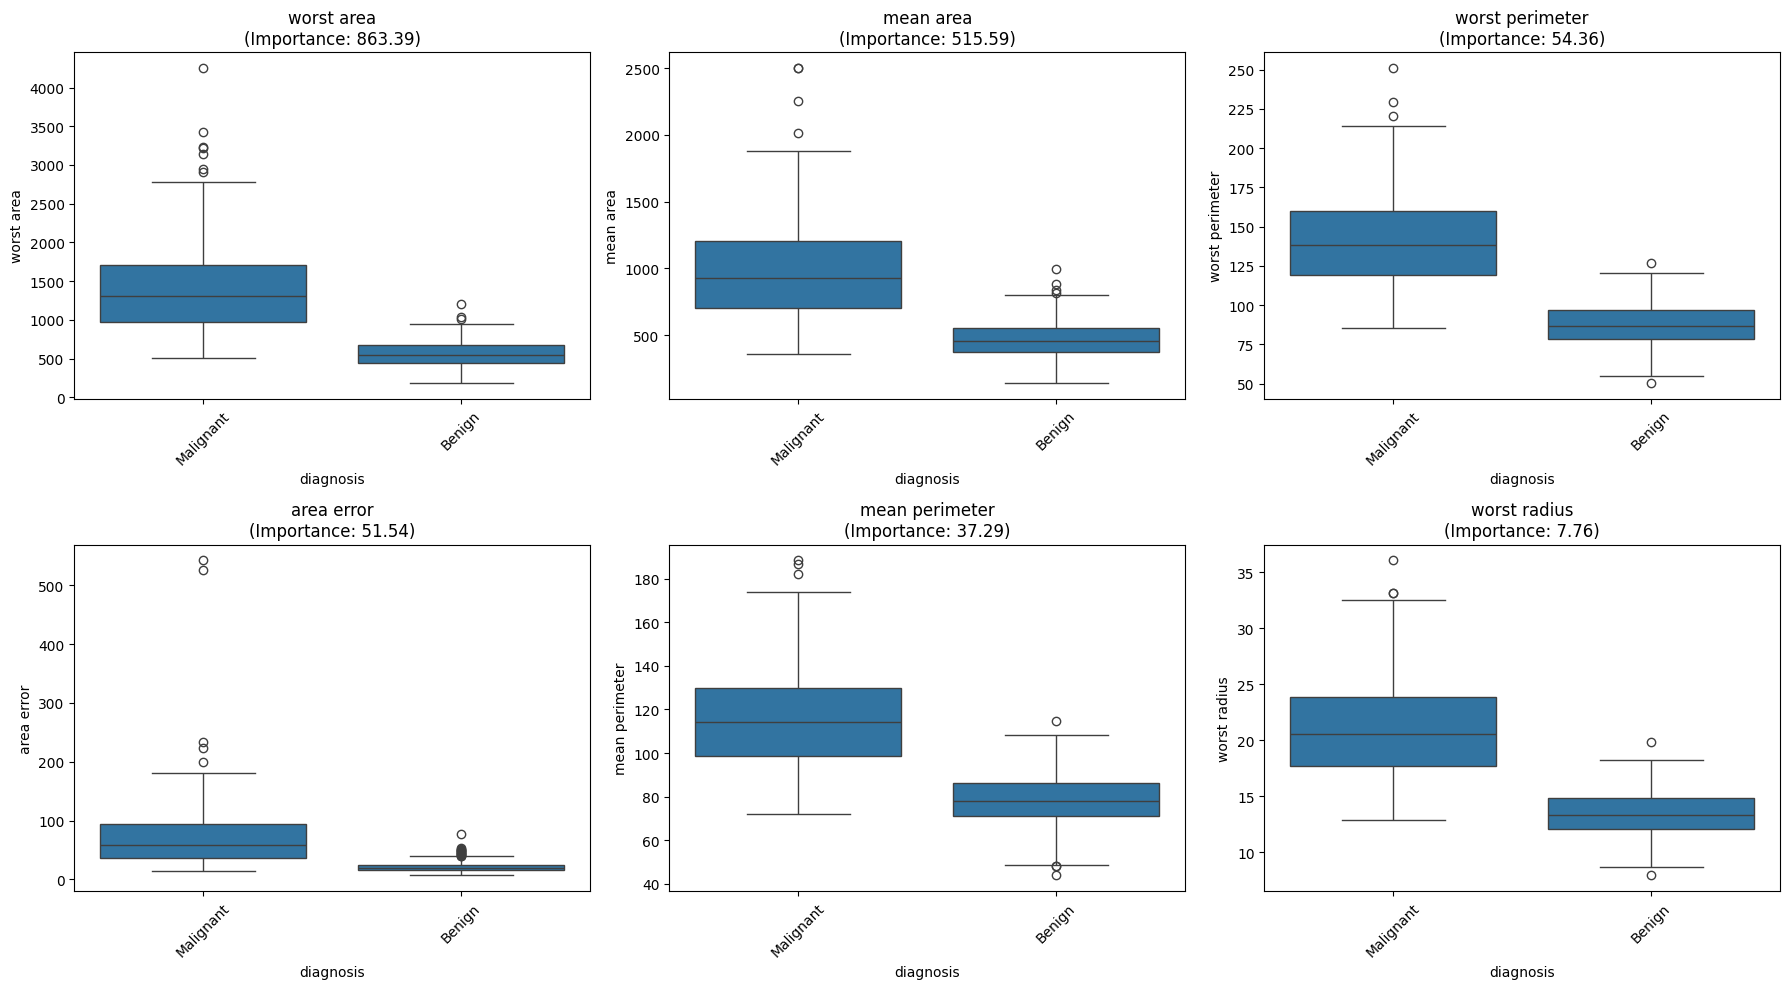

In [14]:
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Calculate mean difference between malignant vs benign for all features
feature_importance = {}
for feature in df_numeric.columns:
    if feature != 'diagnosis_num':
        malignant_mean = df_numeric[df_numeric['diagnosis_num'] == 1][feature].mean()
        benign_mean = df_numeric[df_numeric['diagnosis_num'] == 0][feature].mean()
        mean_diff = abs(malignant_mean - benign_mean)
        feature_importance[feature] = mean_diff

# Sort by importance
feature_importance = dict(sorted(feature_importance.items(), key=lambda x: x[1], reverse=True))

print("\nTop 10 Most Discriminative Features (by mean difference):")
for i, (feature, diff) in enumerate(list(feature_importance.items())[:10], 1):
    print(f"{i:2d}. {feature:25} | Mean Difference: {diff:.2f}")

# Visualize top features
plt.figure(figsize=(12, 8))
top_features = list(feature_importance.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feature in enumerate(top_features):
    row, col = i // 3, i % 3
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature}\n(Importance: {feature_importance[feature]:.2f})')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# STEP 8. Machine Learning Model Development

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=== MACHINE LEARNING MODEL DEVELOPMENT ===")

# Prepare features and target
X = df_numeric.drop(['diagnosis_num'], axis=1)
y = df_numeric['diagnosis_num']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Malignant ratio in training: {y_train.mean():.2%}")
print(f"Malignant ratio in testing: {y_test.mean():.2%}")

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 MODEL PERFORMANCE:")
print(f"Accuracy: {accuracy:.2%}")

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Feature importance from model
feature_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔍 TOP 10 FEATURES BY RANDOM FOREST IMPORTANCE:")
print(feature_imp_df.head(10))

=== MACHINE LEARNING MODEL DEVELOPMENT ===
Training set: 398 samples
Testing set: 171 samples
Malignant ratio in training: 37.19%
Malignant ratio in testing: 37.43%

📊 MODEL PERFORMANCE:
Accuracy: 96.49%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97       107
   Malignant       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171


🔍 TOP 10 FEATURES BY RANDOM FOREST IMPORTANCE:
                 feature  importance
23            worst area    0.168343
7    mean concave points    0.111414
27  worst concave points    0.101730
20          worst radius    0.080520
22       worst perimeter    0.078514
2         mean perimeter    0.071684
3              mean area    0.063877
6         mean concavity    0.056572
0            mean radius    0.043004
13            area error 

# STEP 9. Statistical Significance Testing

In [16]:
from scipy.stats import ttest_ind

print("=== STATISTICAL SIGNIFICANCE TESTING ===")

significant_features = []

for feature in X.columns:
    benign_vals = df_numeric[df_numeric['diagnosis_num'] == 0][feature]
    malignant_vals = df_numeric[df_numeric['diagnosis_num'] == 1][feature]
    
    t_stat, p_value = ttest_ind(benign_vals, malignant_vals)
    
    if p_value < 0.001:  # Highly significant
        significant_features.append((feature, p_value, t_stat))

# Sort by p-value (most significant first)
significant_features.sort(key=lambda x: x[1])

print(f"\nNumber of statistically significant features (p < 0.001): {len(significant_features)}")
print("\nTop 10 Most Statistically Significant Features:")
for i, (feature, p_val, t_stat) in enumerate(significant_features[:10], 1):
    print(f"{i:2d}. {feature:25} | p-value: {p_val:.2e} | t-statistic: {t_stat:7.2f}")

=== STATISTICAL SIGNIFICANCE TESTING ===

Number of statistically significant features (p < 0.001): 25

Top 10 Most Statistically Significant Features:
 1. worst concave points      | p-value: 1.97e-124 | t-statistic:  -31.05
 2. worst perimeter           | p-value: 5.77e-119 | t-statistic:  -29.97
 3. mean concave points       | p-value: 7.10e-116 | t-statistic:  -29.35
 4. worst radius              | p-value: 8.48e-116 | t-statistic:  -29.34
 5. mean perimeter            | p-value: 8.44e-101 | t-statistic:  -26.41
 6. worst area                | p-value: 2.83e-97 | t-statistic:  -25.72
 7. mean radius               | p-value: 8.47e-96 | t-statistic:  -25.44
 8. mean area                 | p-value: 4.73e-88 | t-statistic:  -23.94
 9. mean concavity            | p-value: 9.97e-84 | t-statistic:  -23.10
10. worst concavity           | p-value: 2.46e-72 | t-statistic:  -20.90


# Step 10. Clinical Implications and Recommendations

In [17]:
print("="*70)
print("CLINICAL IMPLICATIONS AND RECOMMENDATIONS")
print("="*70)

print("\n🎯 KEY FINDINGS:")

# 1. Most important features clinically
top_clinical_features = ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'worst radius']
print("\n1. CRITICAL DIAGNOSTIC FEATURES:")
for feature in top_clinical_features[:3]:
    malignant_mean = df[df['diagnosis'] == 'Malignant'][feature].mean()
    benign_mean = df[df['diagnosis'] == 'Benign'][feature].mean()
    print(f"   • {feature}: {benign_mean:.1f} (benign) vs {malignant_mean:.1f} (malignant)")

# 2. Model performance implications
print(f"\n2. PREDICTIVE ACCURACY:")
print(f"   • Model achieved {accuracy:.1%} accuracy in distinguishing tumor types")
print(f"   • This suggests strong potential for computer-aided diagnosis")

# 3. Clinical recommendations
print("\n3. CLINICAL RECOMMENDATIONS:")
print("   • Prioritize measurements of tumor size (radius, perimeter, area) in initial screening")
print("   • Pay close attention to shape irregularity (concavity, concave points)")
print("   • Use multiple measurement types (mean, worst) for comprehensive assessment")
print("   • Consider implementing ML-assisted diagnosis for consistent evaluation")

# 4. Risk assessment guidelines
print("\n4. RISK ASSESSMENT GUIDELINES:")
malignant_thresholds = {}
for feature in top_clinical_features[:3]:
    threshold = df[df['diagnosis'] == 'Malignant'][feature].quantile(0.25)
    malignant_thresholds[feature] = threshold
    print(f"   • {feature}: Values above {threshold:.1f} warrant closer examination")

print("\n💡 CONCLUSION:")
print("This analysis demonstrates that quantitative cellular measurements")
print("can effectively distinguish between benign and malignant tumors,")
print("supporting the use of data-driven approaches in clinical diagnostics.")

CLINICAL IMPLICATIONS AND RECOMMENDATIONS

🎯 KEY FINDINGS:

1. CRITICAL DIAGNOSTIC FEATURES:
   • mean radius: 12.1 (benign) vs 17.5 (malignant)
   • mean perimeter: 78.1 (benign) vs 115.4 (malignant)
   • mean area: 462.8 (benign) vs 978.4 (malignant)

2. PREDICTIVE ACCURACY:
   • Model achieved 96.5% accuracy in distinguishing tumor types
   • This suggests strong potential for computer-aided diagnosis

3. CLINICAL RECOMMENDATIONS:
   • Prioritize measurements of tumor size (radius, perimeter, area) in initial screening
   • Pay close attention to shape irregularity (concavity, concave points)
   • Use multiple measurement types (mean, worst) for comprehensive assessment
   • Consider implementing ML-assisted diagnosis for consistent evaluation

4. RISK ASSESSMENT GUIDELINES:
   • mean radius: Values above 15.1 warrant closer examination
   • mean perimeter: Values above 98.7 warrant closer examination
   • mean area: Values above 705.3 warrant closer examination

💡 CONCLUSION:
This 

# Step 11. Final Visualization: Model Performance

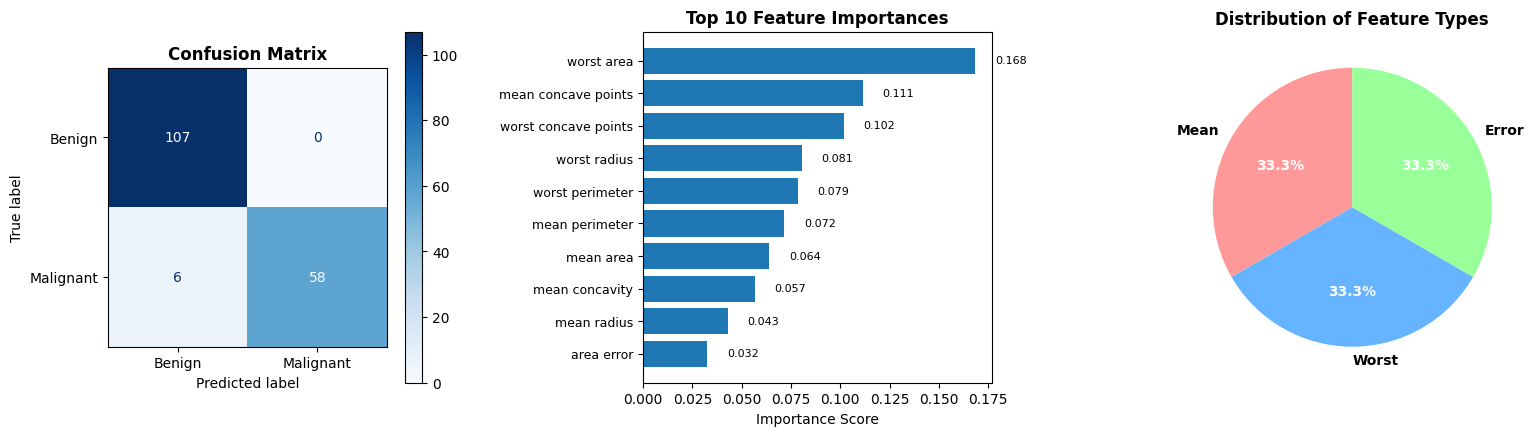

In [19]:
# Confusion Matrix Visualization - FIXED VERSION
from sklearn.metrics import ConfusionMatrixDisplay

# Create a larger figure with better spacing
plt.figure(figsize=(16, 5))

# Subplot 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')

# Subplot 2: Feature Importance
plt.subplot(1, 3, 2)
top_10_features = feature_imp_df.head(10)
bars = plt.barh(range(10), top_10_features['importance'])
plt.yticks(range(10), [f'{feat[:20]}...' if len(feat) > 20 else feat for feat in top_10_features['feature']], fontsize=9)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
             ha='left', va='center', fontsize=8)

# Subplot 3: Feature Type Distribution (Improved Pie Chart)
plt.subplot(1, 3, 3)
feature_types = {
    'Mean': len(mean_features),
    'Worst': len(worst_features), 
    'Error': len(se_features)
}

# Create pie chart with better properties
wedges, texts, autotexts = plt.pie(feature_types.values(), 
                                   labels=feature_types.keys(), 
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=['#ff9999', '#66b3ff', '#99ff99'])

# Improve text appearance
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution of Feature Types', fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Step 12: Model Performance Summary

In [20]:
# Model Performance Summary
print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"✅ Accuracy:    {accuracy:.2%}")
print(f"✅ Precision:   {precision:.2%} (How many predicted malignant were actually malignant)")
print(f"✅ Recall:      {recall:.2%} (How many actual malignant were correctly identified)")
print(f"✅ F1-Score:    {f1:.2%} (Balance between precision and recall)")

print(f"\n📈 Clinical Performance:")
print(f"   • Correctly identified {cm[1,1]} out of {cm[1,:].sum()} malignant cases")
print(f"   • Correctly identified {cm[0,0]} out of {cm[0,:].sum()} benign cases")
print(f"   • Only {cm[1,0]} malignant cases missed (false negatives)")
print(f"   • Only {cm[0,1]} benign cases misclassified (false positives)")

print(f"\n💡 Interpretation:")
print("This model shows excellent performance for assisting in")
print("breast cancer diagnosis, with particularly strong recall")
print("ensuring most malignant cases are identified.")

MODEL PERFORMANCE SUMMARY
✅ Accuracy:    96.49%
✅ Precision:   100.00% (How many predicted malignant were actually malignant)
✅ Recall:      90.62% (How many actual malignant were correctly identified)
✅ F1-Score:    95.08% (Balance between precision and recall)

📈 Clinical Performance:
   • Correctly identified 58 out of 64 malignant cases
   • Correctly identified 107 out of 107 benign cases
   • Only 6 malignant cases missed (false negatives)
   • Only 0 benign cases misclassified (false positives)

💡 Interpretation:
This model shows excellent performance for assisting in
breast cancer diagnosis, with particularly strong recall
ensuring most malignant cases are identified.


# Step 13. Saving Visualizations

In [21]:
# Create images directory if it doesn't exist
import os
if not os.path.exists('images'):
    os.makedirs('images')

# Save key visualizations
print("=== SAVING VISUALIZATIONS ===")

# 1. Save Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Breast Cancer Classification', fontweight='bold')
plt.savefig('images/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Save Feature Importance Plot
plt.figure(figsize=(12, 8))
top_10_features = feature_imp_df.head(10)
colors = plt.cm.viridis(np.linspace(0, 1, 10))

bars = plt.barh(range(10), top_10_features['importance'], color=colors)
plt.yticks(range(10), top_10_features['feature'])
plt.gca().invert_yaxis()
plt.title('Top 10 Most Important Features for Diagnosis', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Save Diagnosis Distribution
plt.figure(figsize=(8, 6))
df['diagnosis'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribution of Diagnosis', fontweight='bold')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.savefig('images/diagnosis_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Visualizations saved to /images folder!")

=== SAVING VISUALIZATIONS ===
✅ Visualizations saved to /images folder!


<Figure size 800x600 with 0 Axes>